# [3주차] Transformer 과제

- **과제 목적:** 이번 과제는 하나의 흐름 안에서 Transformer의 핵심 연산을 직접 구현하고, 마스킹 전후를 비교한 뒤, BERT와 GPT의 예측 방식을 관찰하는 과제로 출제해봤습니다. 완성된 코드를 실행하는 것에서 끝내지 않고, 실제로 실행하며 얻은 수치와 출력 결과를 근거로 각 개념을 해석하면서 트랜스포머를 이해해주시면 됩니다!

## 전체 흐름

> Scaled Dot-Product Attention 구현 → Causal Mask 적용 → BERT와 GPT 결과 비교 → 전체 해석

### 제출 시 유의사항
- 코드 셀의 `TODO`와 주석의 빈칸을 모두 채워주세요.
- 서술형 답변은 **본인이 실행해 얻은 값이나 출력**을 반드시 이용해서 작성해주세요.
- 마지막 셀의 생성형 AI 활용 내역을 반드시 작성해주세요.


## 0. 환경 설정

아래 셀을 실행하여 필요한 라이브러리를 설치하고 시드를 고정합니다.

In [ ]:
!pip -q install transformers

import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Hugging Face의 다운로드 진행바/경고를 줄여 과제 출력이 너무 길어지지 않게 합니다.
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    AutoModelForCausalLM,
)
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)


device: cpu


# 1. 필수 과제

## 1-1. Scaled Dot-Product Attention 직접 구현

다음 식을 코드로 구현합니다.

$$
\mathrm{Attention}(Q,K,V)
=\mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

아래 예제에서 각 행은 하나의 토큰을 나타냅니다. 코드의 빈칸과 주석을 채운 뒤, **Attention Score → Weight → Output**의 흐름을 확인해주세요.


In [ ]:
# 세 토큰의 Q, K, V 예시
Q = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
])

# 첫 번째 Query에서 최대 Attention이 하나만 나오도록 세 번째 Key를 [0.5, 0.5]로 둡니다.
K = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [0.5, 0.5],
])

V = torch.tensor([
    [10.0, 0.0],
    [0.0, 10.0],
    [5.0, 5.0],
])


def scaled_dot_product_attention(Q, K, V, mask=None):
    # [빈칸] d_k는 어떤 벡터의 차원을 뜻하는가?
    # 답: _Query와 Key 벡터의 차원
    d_k = Q.size(-1)

    # TODO 1: Query와 모든 Key의 내적 계산
    scores = Q @ K.T

    # TODO 2: 내적값을 sqrt(d_k)로 나누기
    scaled_scores = scores / math.sqrt(d_k)

    # Mask가 주어진 경우 미래 위치의 score를 -inf로 바꿉니다.
    if mask is not None:
        scaled_scores = scaled_scores.masked_fill(mask, float('-inf'))

    # TODO 3: 마지막 차원에 Softmax를 적용해 Attention Weight 구하기
    weights = torch.softmax(scaled_scores, dim=-1)

    # TODO 4: Attention Weight와 Value의 가중합 계산
    output = weights @ V

    return scores, scaled_scores, weights, output

scores, scaled_scores, weights, output = scaled_dot_product_attention(Q, K, V)

print("[Raw Attention Scores]\n", scores)
print("\n[Scaled Scores]\n", scaled_scores)
print("\n[Attention Weights]\n", weights)
print("\n[Attention Output]\n", output)


[Raw Attention Scores]
 tensor([[1.0000, 0.0000, 0.5000],
        [0.0000, 1.0000, 0.5000],
        [1.0000, 1.0000, 1.0000]])

[Scaled Scores]
 tensor([[0.7071, 0.0000, 0.3536],
        [0.0000, 0.7071, 0.3536],
        [0.7071, 0.7071, 0.7071]])

[Attention Weights]
 tensor([[0.4555, 0.2246, 0.3199],
        [0.2246, 0.4555, 0.3199],
        [0.3333, 0.3333, 0.3333]])

[Attention Output]
 tensor([[6.1546, 3.8454],
        [3.8454, 6.1546],
        [5.0000, 5.0000]])


In [ ]:
# 과정 확인 장치: 각 Query의 Attention Weight 합은 1이어야 합니다.
row_sums = weights.sum(dim=-1)
print("각 행의 합:", row_sums)

# TODO 5: row_sums가 모두 1에 가까운지 검증
assert torch.allclose(row_sums, torch.ones_like(row_sums))

# 첫 번째 Query가 가장 크게 참고한 Key의 인덱스
most_attended_key = weights[0].argmax().item()
print("첫 번째 Query가 가장 크게 참고한 Key index:", most_attended_key)


각 행의 합: tensor([1., 1., 1.])
첫 번째 Query가 가장 크게 참고한 Key index: 0


### 1-1 결과 해석

1. 첫 번째 Query가 가장 크게 참고한 Key의 인덱스와 가중치는 얼마인가요?
   - **답:** Keyindex는 0이고 가중치는 약 0.456이다.

2. 그 Key의 가중치가 가장 큰 이유를 Q와 K의 내적 관점에서 설명해주세요.
   - **답:**첫 번째 Query [1, 0]과 각 Key의 내적은 각각 1, 0, 0.5이다. 이중 Key 0광의 내적이 1로 가장 크기 때문에 두 벡터의 유사도가 가장 높다고 판단되어 가장 큰 Attention Weight를 받는다.

3. Attention Output은 Value 하나를 그대로 선택한 결과인가요, 여러 Value를 결합한 결과인가요?
   - **답:** 하나의 Value를 그대로 선택하는 것이 아니라 여러 Value에 Attention Weight를 곱한 뒤 모두 더한 가중합 결과이다.

4. `sqrt(d_k)`로 나누는 Scaling이 필요한 이유를 Softmax와 연결해 설명해주세요.
   - **답:** d_k가 커지면 Q와 K의 내적값도 커질 수 있는데 큰 값을 그대로 Softmax에 넣으면 특정 값의 확률이 지나치게 1에 가까워져 분포가 극단적으로 변한다. 따라서 sqrt(d_k)로 나누어 값의 크기를 조절하고 Softmax가 너무 한쪽으로 치우치는 것을 방지하여 안정적으로 학습할 수 있도록 한다.


## 1-2. Look-ahead Mask 적용하기

같은 Q, K, V에 **Causal Mask(Look-ahead Mask)** 를 적용해 미래 토큰을 보지 못하게 합니다. 마스크 자체와 Masked Self-Attention은 같은 말이 아닙니다.

- **Look-ahead Mask:** 미래 위치를 가리는 마스크
- **Masked Self-Attention:** Self-Attention에 Look-ahead Mask를 적용한 연산

In [ ]:
seq_len = Q.size(0)

# TODO 1: 주대각선 위쪽을 True로 갖는 마스크 만들기
# 힌트: torch.triu(..., diagonal=1)
causal_mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool), diagonal=1)

_, _, unmasked_weights, _ = scaled_dot_product_attention(Q, K, V)
_, _, masked_weights, masked_output = scaled_dot_product_attention(
    Q, K, V, mask=causal_mask
)

print("[Causal Mask]\n", causal_mask)
print("\n[Mask 적용 전 Weight]\n", unmasked_weights)
print("\n[Mask 적용 후 Weight]\n", masked_weights)
print("\n[Masked Attention Output]\n", masked_output)


[Causal Mask]
 tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])

[Mask 적용 전 Weight]
 tensor([[0.4555, 0.2246, 0.3199],
        [0.2246, 0.4555, 0.3199],
        [0.3333, 0.3333, 0.3333]])

[Mask 적용 후 Weight]
 tensor([[1.0000, 0.0000, 0.0000],
        [0.3302, 0.6698, 0.0000],
        [0.3333, 0.3333, 0.3333]])

[Masked Attention Output]
 tensor([[10.0000,  0.0000],
        [ 3.3024,  6.6976],
        [ 5.0000,  5.0000]])


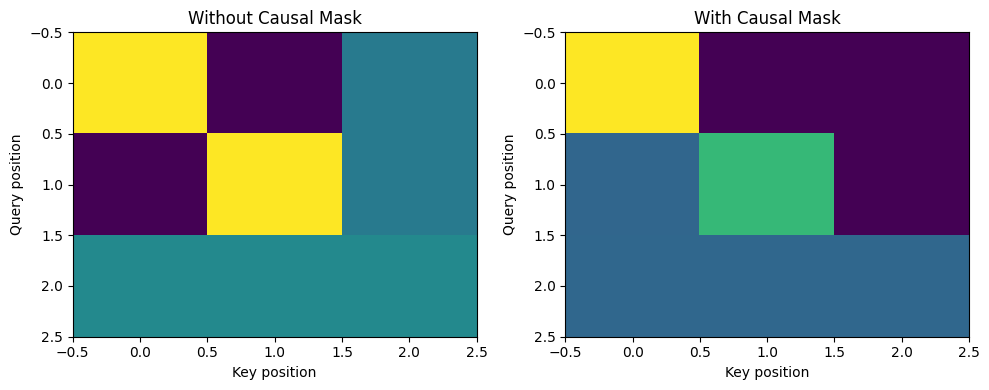

In [ ]:
# Attention Weight 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(unmasked_weights.detach().numpy(), aspect="auto")
axes[0].set_title("Without Causal Mask")
axes[0].set_xlabel("Key position")
axes[0].set_ylabel("Query position")

axes[1].imshow(masked_weights.detach().numpy(), aspect="auto")
axes[1].set_title("With Causal Mask")
axes[1].set_xlabel("Key position")
axes[1].set_ylabel("Query position")

plt.tight_layout()
plt.show()

### 1-2 결과 해석

1. Query index 0은 마스크 적용 후 어느 Key까지 참고할 수 있나요?
   - **답:** Query index 0은 Key index 0까지만 참고할 수 있다. 미래 위치인 Key index 1, 2, 3 등은 마스크에 의해 차단된다.

2. 마스크 적용 후 Weight 행렬이 삼각형 모양이 되는 이유를 설명해주세요.
   - **답:** 각 Query는 자기 자신과 이전 위치의 Key만 참고할 수 있고 미래 위치의 Key는 참고할 수 없기 때문이다. 따라서 미래 위치의 Weight가 0이 되어 행렬이 삼각형 모양으로 나타난다.

3. Look-ahead Mask를 적용한 위치의 Weight가 0이 되는 과정을 `-∞ → Softmax`와 연결해 서술해주세요.
   - **답:** 마스크가 적용된 미래 위치의 Attention Score를 -∞로 바꾼 뒤 Softmax를 적용한다. 이때 exp(-∞)=0이므로 해당 위치의 Attention Weight는 0이 되어 정보를 참고하지 못하게 된다.

4. Padding Mask와 Look-ahead Mask의 목적의 차이를 한 문장씩 간단하게 작성해주세요.
   - **Padding Mask:** 문장의 길이를 맞추기 위해 추가된 패딩 토큰을 Attention 계산에서 제외하기 위한 마스크이다.
  
   - **Look-ahead Mask:** 현재 위치에서 미래 토큰의 정보를 미리 참고하지 못하도록 차단하는 마스크이다.


## 1-3. BERT와 GPT의 예측 방식 비교

이제 사전학습 모델을 사용해 두 모델의 차이를 관찰합니다.

- **BERT:** Encoder 기반, 양방향 문맥, Masked Language Model
- **GPT:** Decoder 기반, Causal Mask, 이전 토큰만 이용하는 Autoregressive Language Model

두 모델은 목적이 다르므로 정확도 경쟁이 아니라, **입력과 예측 방식의 차이**를 해석하는 것이 핵심입니다.

In [ ]:
# 모델 불러오기
bert_name = "bert-base-uncased"
gpt_name = "gpt2"

# TODO 1: BERT tokenizer와 Masked LM model 불러오기
bert_tokenizer = AutoTokenizer.from_pretrained(bert_name)
bert_model = AutoModelForMaskedLM.from_pretrained(bert_name)
_ = bert_model.eval()

# TODO 2: GPT tokenizer와 Causal LM model 불러오기
gpt_tokenizer = AutoTokenizer.from_pretrained(gpt_name)
gpt_model = AutoModelForCausalLM.from_pretrained(gpt_name)
_ = gpt_model.eval()

print("BERT / GPT 모델 로드 완료")


BERT / GPT 모델 로드 완료


In [ ]:
# ----- BERT: [MASK]의 앞뒤 문맥을 모두 이용한 단어 예측 -----
# [MASK] 뒤의 "to withdraw money"까지 활용할 수 있다는 점이 핵심
bert_sentence = "I went to the [MASK] to withdraw money."
bert_inputs = bert_tokenizer(bert_sentence, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    bert_logits = bert_model(**bert_inputs).logits

mask_positions = (bert_inputs["input_ids"] == bert_tokenizer.mask_token_id).nonzero(as_tuple=False)
assert len(mask_positions) == 1, "[MASK] 토큰은 정확히 하나만 있어야 합니다."
mask_index = mask_positions[0, 1].item()
mask_logits = bert_logits[0, mask_index, :]

# TODO 3: logit이 높은 상위 5개 토큰의 id 구하기
bert_top_ids = torch.topk(mask_logits, k=5).indices.tolist()
bert_top_tokens = [bert_tokenizer.decode([idx]).strip() for idx in bert_top_ids]
print("문장:", bert_sentence)
print("BERT top-5 predictions:", bert_top_tokens)


문장: I went to the [MASK] to withdraw money.
BERT top-5 predictions: ['bank', 'banks', 'store', 'atm', 'office']


In [ ]:
# ----- GPT: 지금까지의 토큰만 이용한 다음 토큰 예측 -----
# GPT는 뒤 문맥을 볼 수 없으므로, 현재까지 주어진 prefix에서 다음 토큰을 예측
gpt_prompt = "I went to the bank to withdraw"
gpt_inputs = gpt_tokenizer(gpt_prompt, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    gpt_logits = gpt_model(**gpt_inputs).logits

next_token_logits = gpt_logits[0, -1, :]

# TODO 4: 다음 토큰 후보 상위 5개의 id 구하기
gpt_top_ids = torch.topk(next_token_logits, k=5).indices.tolist()
gpt_top_tokens = [gpt_tokenizer.decode([idx]) for idx in gpt_top_ids]
print("Prompt:", gpt_prompt)
print("GPT next-token top-5:", gpt_top_tokens)


Prompt: I went to the bank to withdraw
GPT next-token top-5: [' money', ' my', ' the', ' $', ' some']


In [ ]:
# GPT의 Autoregressive 생성 과정 관찰
prompt = "In natural language processing, Transformer models can"
inputs = gpt_tokenizer(prompt, return_tensors="pt").to(DEVICE)

# TODO 5: max_new_tokens=20, do_sample=False 조건으로 문장 생성
generated_ids = gpt_model.generate(
    **inputs,
    max_new_tokens=20,
    do_sample=False,
    pad_token_id=gpt_tokenizer.eos_token_id,
)

print(gpt_tokenizer.decode(generated_ids[0], skip_special_tokens=True))


In natural language processing, Transformer models can be used to create a model that is more accurate than the original model.

Transformer models


### 1-3 결과 해석

> **주의:** BERT/GPT의 상위 토큰과 생성 문장은 라이브러리·모델 버전에 따라 조금 달라질 수 있습니다. 반드시 **본인의 실제 출력값을 사용해** 답변을 작성해주시면 됩니다!

1. BERT의 `[MASK]` 상위 5개 예측 중 문맥상 가장 적절하다고 판단한 토큰은 무엇인가요? 그 이유는 무엇인가요?
   - **답:** bank이다. "I went to the [MASK] to withdraw money." 이므로 돈을 인출하러 가는 장소인 bank가 가장 자연스럽다.
2. GPT의 다음 토큰 상위 5개 중 자연스럽다고 판단한 후보 2개를 적고, 그 이유도 설명해주세요.
   - **답:** money, some이다. "I went to the bank to withdraw" 뒤에는 "money"가 직접 이어져 돈을 인출하다라는 자연스러운 문장이 된다. some도 뒤에 money와 같은 명사가 이어질 수 있어 withdraw some money라는 자연스러운 표현을 만들 수 있다.

3. BERT와 GPT의 차이를 **Bidirectional / Causal / Masked Self-Attention** 용어를 사용해 설명해주세요.
   - **답:** BERT는 Bidirectional Self-Attention을 사용하여 특정 단어를 예측할 때 앞과 뒤의 문맥을 모두 참고한다. 반면 GPT는 Casual Masked Self Attention을 사용하여 현재 위치보다 미래에 있는 토큰을 볼 수 없고 오직 이전까지의 토큰만 이용해 다음 토큰을 예측한다.

4. GPT의 생성 결과를 **Autoregressive** 관점에서 서술해주세요.
   - **답:** GPT는 Autoregressive방식으로 문장을 생성한다. 즉 현재까지 입력된 토큰들을 이용해 다음 토큰 하나를 예측하고 그 토큰을 다시 입력에 추가한 뒤 다음 토큰을 예측하는 과정을 반복한다. 따라서 이번 결과라도 "In natural language processing, Transformer models can"이라는 문장 뒤에 토큰을 하나씩 순차적으로 생성하여 최종 문장을 완성한 결과이다. 또한 do_sample=False이므로 각 단계에서 확률이 높은 토큰을 선택하는 방식으로 생성이 진행된다.


# 2. 심화 과제 (선택)

아래 **A/B 중 하나를 선택**하여 수행하세요. 선택한 실험에서는 코드 실행 결과뿐 아니라 **본인이 관찰한 출력값이나 문장 일부를 근거로 해석**해야 합니다.

---

## A안. BERT의 서로 다른 Attention Head 비교

같은 문장을 넣고 BERT의 동일 Layer 안에서 서로 다른 Head가 **특정 Query 토큰(`it`)에서 어떤 Key 토큰을 참고하는지** 비교합니다.

- 비교 문장: `The animal did not cross the street because it was tired.`
- 비교 Layer: 중간층인 Encoder Layer 8 (0-based index 7)
- 비교 Head: Head 0, Head 1
- 비교 Query: `it`
- 확인할 점: 두 Head가 `it`에서 어떤 토큰에 서로 다른 Attention을 주는지

> 마지막 Layer의 전체 Attention heatmap은 `[SEP]` 같은 특수 토큰에 Attention이 몰려 Head 차이가 잘 안 보일 수 있습니다. 따라서 **중간 Layer + 특정 Query 행**을 비교합니다.


tokens: ['[CLS]', 'the', 'animal', 'did', 'not', 'cross', 'the', 'street', 'because', 'it', 'was', 'tired', '.', '[SEP]']
layer attention shape: torch.Size([12, 14, 14])
query token: it (index 9 )


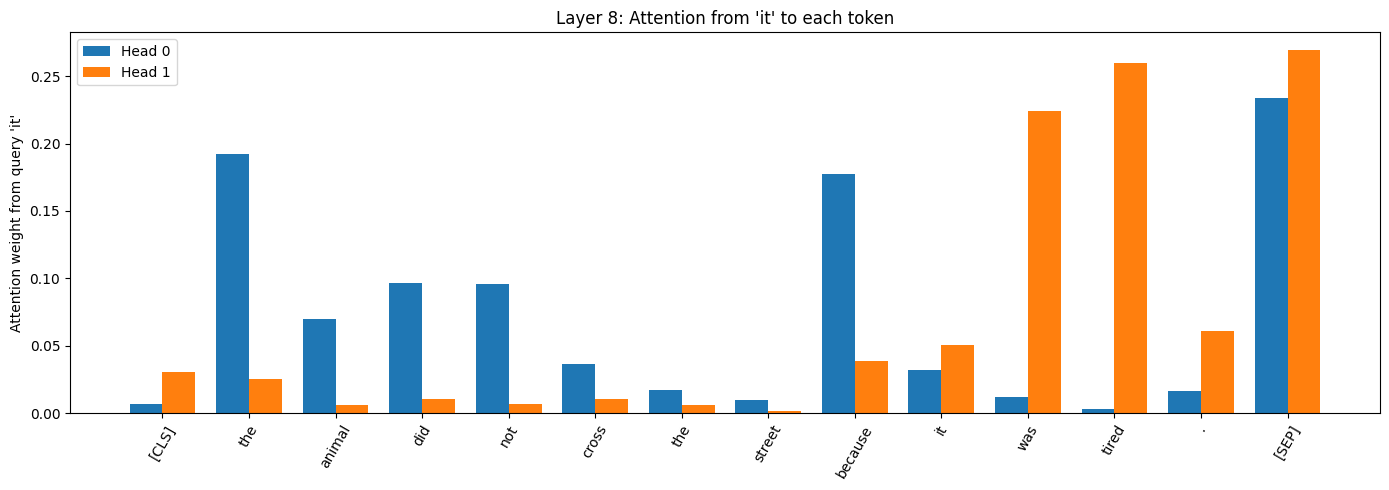

Head 0: 'it'이 가장 크게 참고한 일반 토큰 = 'the' (index=1, weight=0.1923)
Head 1: 'it'이 가장 크게 참고한 일반 토큰 = 'tired' (index=11, weight=0.2598)
Head 0과 Head 1의 'it' attention 분포 평균 절대 차이: 0.084319


In [ ]:
# A안: BERT Multi-Head Attention 비교
from transformers import AutoModel

# attention weight를 반환하도록 eager 구현을 사용합니다.
bert_attn_model = AutoModel.from_pretrained(
    bert_name,
    attn_implementation="eager",
).to(DEVICE)
_ = bert_attn_model.eval()

attn_sentence = "The animal did not cross the street because it was tired."
attn_inputs = bert_tokenizer(attn_sentence, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    attn_outputs = bert_attn_model(**attn_inputs, output_attentions=True)

# attentions: tuple(num_layers), 각 원소 shape = [batch, num_heads, seq_len, seq_len]
attentions = attn_outputs.attentions
assert attentions is not None, "Attention이 반환되지 않았습니다. attn_implementation='eager' 설정을 확인하세요."

tokens = bert_tokenizer.convert_ids_to_tokens(attn_inputs["input_ids"][0])

# TODO 1: 8번째 Encoder layer(0-based index 7)를 선택
layer_idx = 7
layer_attn = attentions[layer_idx][0].detach().cpu()

# TODO 2: Query 토큰 'it'의 위치 찾기.
it_idx = tokens.index("it")

# TODO 3: Head 0과 Head 1에서 Query='it'이 모든 Key 토큰에 주는 Attention 가져오기
head0_it = layer_attn[0, it_idx, :]
head1_it = layer_attn[1, it_idx, :]

print("tokens:", tokens)
print("layer attention shape:", layer_attn.shape)
print("query token:", tokens[it_idx], "(index", it_idx, ")")

# 특수 토큰까지 포함한 전체 분포를 막대그래프로 비교
x = np.arange(len(tokens))
width = 0.38
plt.figure(figsize=(14, 5))
plt.bar(x - width/2, head0_it.numpy(), width, label="Head 0")
plt.bar(x + width/2, head1_it.numpy(), width, label="Head 1")
plt.xticks(x, tokens, rotation=60)
plt.ylabel("Attention weight from query 'it'")
plt.title(f"Layer {layer_idx+1}: Attention from 'it' to each token")
plt.legend()
plt.tight_layout()
plt.show()

# 각 Head에서 'it'이 가장 많이 참고한 일반 토큰 확인
# [CLS], [SEP]는 해석을 위해 제외합니다.
special_ids = {0, len(tokens)-1}
valid_indices = [i for i in range(len(tokens)) if i not in special_ids]

def top_key_for_head(weights, valid_indices):
    best = max(valid_indices, key=lambda i: float(weights[i]))
    return best, tokens[best], float(weights[best])

for h, w in [(0, head0_it), (1, head1_it)]:
    idx, tok, val = top_key_for_head(w, valid_indices)
    print(f"Head {h}: 'it'이 가장 크게 참고한 일반 토큰 = {tok!r} (index={idx}, weight={val:.4f})")

mean_abs_diff = torch.mean(torch.abs(head0_it - head1_it)).item()
print(f"Head 0과 Head 1의 'it' attention 분포 평균 절대 차이: {mean_abs_diff:.6f}")


### A안 결과 해석

- **선택:** A
- **변경한 조건:** Encoder Layer(0-based index 7)에서 Query 토큰을 it으로 고정하고 Head 0과 Head 1이 각 Key 토큰에 주는 Attention Weight를 비교하였다.


- **관찰 결과:** Head 0과 Head 1에서 `it`이 가장 크게 참고한 토큰과 가중치를 각각 실제 출력값을 이용해서 설명해주세요.
실제 출력 결과에서 Head 0은 it이 일반 토큰 중 'the'(index=1)를 가장 크게 참고했으며 Attention Weight는 0.1923이었다. 반면 Head 1은 'tired'(index=11)를 가장 크게 참고했고 Attention Weight는 0.2598이었다. 따라서 같은 it이라는 Query에 대해서도 Head에 따라 중요하게 참고하는 토큰이 다르게 나타났으며 두 Head의 Attention 분포 평균 절대 차이는 0.084319였다.

- **해석:** 두 Head의 Attention 분포가 왜 다를 수 있는지 Multi-Head Attention의 Q/K/V projection과 연결하여 설명하세요.
Multi-Head Attention에서는 각 Head가 서로 다른 학습된 Q(Query), K(Key), V(Value) projection 행렬을 사용한다. 따라서 같은 it 토큰이라도 Head마다 서로 다른 Q 벡터가 만들어지고 각 토큰의 K벡터와 계산되는 유사도도 달라지므로 Attention Weight가 서로 다르게 나타날 수 있다. 이번 결과에서도 Head 0은 'the'에 상대적으로 높은 Attention을 주는 반면 Head 1은 it과 의미적으로 연결되는 'tired'에 높은 Attention을 주었다. 이는 여러 Head가 문장의 서로 다른 관계나 특징을 동시에 학습할 수 있음을 보여준다.

---

## B안. GPT Temperature에 따른 생성 다양성 비교

같은 Prompt에서 **temperature만 변경**했을 때 생성 결과의 다양성과 자연스러움이 어떻게 달라지는지 비교합니다.

- Prompt는 모든 실험에서 동일하게 유지합니다.
- `temperature = 0.3, 0.8, 1.5`를 비교합니다.
- 각 temperature에서 **3회 생성**합니다.
- `top_k=50`, 생성 길이 등 나머지 조건은 동일하게 유지합니다.
- 생성 결과의 **다양성(Diversity)** 과 **문맥의 자연스러움(Coherence)** 을 비교합니다.

### 확인할 질문
1. 어느 temperature에서 3개의 생성 결과가 가장 비슷했고, 어느 temperature에서 가장 다양했나요? 실제 생성 문장의 일부를 근거로 설명해세요.
2. temperature가 높아질수록 문장의 자연스러움과 다양성이 어떻게 변했나요? 예상과 다른 결과가 나왔다면 그 결과도 그대로 편하게 적어주세요.
3. temperature가 Softmax 확률분포에 미치는 영향을 위 실험 결과와 연결해 설명하세요.


In [ ]:
# B안: temperature에 따른 GPT 생성 다양성 비교
# 여러 방향으로 자연스럽게 이어질 수 있는 prompt를 사용합니다.
prompt = "Once upon a time, a robot discovered"

# TODO 1: 비교할 temperature 값을 입력
temps = [____, ____, ____]

# top_k, 생성 길이 등은 모든 조건에서 동일하게 고정하고
# temperature만 변경하여 그 효과를 비교합니다.
for temp in temps:
    print(f"\n===== temperature={temp} =====")

    # 같은 temperature에서도 3번 생성하여 결과의 다양성을 확인합니다.
    for trial in range(3):
        # 각 temperature에서 같은 trial끼리는 동일한 seed를 사용합니다.
        torch.manual_seed(SEED + trial)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED + trial)

        temp_inputs = gpt_tokenizer(
            prompt,
            return_tensors="pt"
        ).to(DEVICE)

        generated = gpt_model.generate(
            **temp_inputs,
            # TODO 2: 새롭게 생성할 토큰 수를 40으로 설정
            max_new_tokens=____,
            # TODO 3: sampling을 사용하도록 설정
            do_sample=____,
            # TODO 4: 현재 반복문의 temperature를 적용
            temperature=____,
            # 모든 조건에서 동일하게 유지합니다.
            top_k=50,
            pad_token_id=gpt_tokenizer.eos_token_id,
        )

        text = gpt_tokenizer.decode(
            generated[0],
            skip_special_tokens=True
        )

        print(f"\n[생성 {trial + 1}]")
        print(text)


### B안 결과 해석

- **선택:** B
- **변경한 조건:** 어떤 조건을 고정하고 무엇만 변경했는지 작성하세요.
- **관찰 결과:** temperature별 3개의 실제 생성 결과를 비교하고, 구체적인 문장 일부를 인용하세요.
- **해석:** `temperature → Softmax 확률분포 → 다양성/자연스러움`의 관계를 설명하세요.
- **주의:** Sampling 결과는 확률적이므로 이론적인 경향과 완벽하게 일치하지 않을 수 있습니다. 예상과 다른 결과가 나오더라도 실제 출력값을 근거로 타당하게 해석하세요.


# 3. 전체 결과 정리 및 회고

아래 표를 **본인의 실제 실행 결과**를 바탕으로 채워주세요.

| 단계 | 본인이 관찰한 핵심 결과 | 연결되는 개념 |
|---|---|---|
| Attention 직접 구현 | Q와 K의 내적을 통해 Attentiton Score를 구하고 Softmax를 적용하자 각 Query의 Attention Weight의 합이 1이 되었으며 여러 Value를 가중합하여 Attention Output이 만들어졌다.  | Scaled Dot-Product Attention, Q/K/V, Softmax, Weighted Sum |
| Causal Mask 적용 | 마스크 적용 후 현재 Query가 미래 Key를 참고하는 위치의 Weight가 0이 되었고, Attention Weight가 삼각형 형태로 나타났다.  | Casual Mask, Look-ahead Mask, -∞ → Softmax → 0 |
| BERT 실험 | "I went to the [MASK] to withdraw money."에서 bank, banks, store, atm, office 순으로 예측되었으며 bank가 가장 높은 순위로 나타났다.  | Bidirectional Self Attention, Masked Language Model |
| GPT 실험 | "I went to the bank to withdraw" 다음 토큰으로 money, my the, $, some이 상위 5개로 나타났고 문장 생성에서는 토큰을 하나씩 이어 "Transformer models can be used to create..."와 같은 결과를 생성했다.  | Casual Masked Self-Attention, Casual LM, Autoregressive Generation |

1. **가장 어려웠던 단계와 해결 방법**
   - 답: Casual Mask를 직접 적용하는 과정이 가장 어려웠다. 처음에는 마스크의 자료형이 float이라서 masked_fill()에서 오류가 발생했는데 torch.bool 타입으로 마스크를 생성하여 해결하였다. 또한 주 대각선 위쪽을 True로 설정하여 미래 토큰의 Attention Score가 차단되도록 구현하였다.

2. **실행 전 예상과 실제 결과가 가장 달랐던 부분**
   - 답: BERT의 [MASK] 예측 결과가 가장 예상과 달랐다. "withdraw money"라는 표현 때문에 ATM이 가장 높은 순위로 나올 것이라고 예상했지만 실제로는 bank가 1순위이고 atm은 4순위로 나타났다. 이를 통해 모델의 예측은 단순히 의미적으로 가장 구체적인 단어를 선택하는 것이 아니라 전체 문맥과 학습 데이터에서 학습한 언어적 패턴을 바탕으로 결정된다는 점을 확인할 수 있었다.

3. **기술블로그의 ‘과제 복습’ 섹션에 정리할 핵심 개념**
   - 답: transformer의 핵심인 Q, K, V를 이용한 Scaled Dot-Product Attention, Softmax를 통한 Attention Weight 계산, 미래 토큰을 차단하는 Casual Mask, 그리고 BERT와 GPT의 Attention 방식 차이를 정리할 것이다. 특히 BERT는 Bidirectional Self Attention으로 앞뒤 문맥을 모두 활용해 [MASK]를 예측하는 반면, GPT는 Casual Masked Self-Attention으로 이전 토큰만 참고하고 Autoregressive 방식으로 다음 토큰을 하나씩 생성한다는 차이를 핵심적으로 정리할 수 있다.


# 4. 생성형 AI 활용 방법 및 대화 내역

> **반드시 작성하세요.** 문제를 풀면서 GPT, Claude 등 생성형 AI를 어디에 어떻게 사용했는지 기록합니다.

## 1) 활용한 생성형 AI
- 사용한 도구: Chat-GPT
- 사용한 문제/단계: BERT [MASK] 예측
- 사용 목적: ` 오류 해결 / 결과 해석 `

## 2) AI 답변을 그대로 사용하지 않고 직접 검증한 방법
- 답:ChatGPT가 제시한 코드를 Google Colab에서 직접 실행하여 정상적으로 동작하는지 확인하였다. 특히 Causal Mask 구현 과정에서는 처음 작성한 마스크가 float 자료형이어서 masked_fill() 오류가 발생했고, 실제 오류 메시지를 확인한 뒤 마스크를 torch.bool 자료형으로 수정하여 다시 실행하였다. 또한 BERT와 GPT의 예측 결과는 AI의 설명만 사용하지 않고 실제 출력된 상위 토큰을 직접 확인하였다. BERT에서는 bank, banks, store, atm, office가 출력되었고, GPT에서는 money, my, the, $, some이 출력되는 것을 확인한 뒤 실제 결과를 바탕으로 해석하였다. Multi-Head Attention 역시 직접 실행한 그래프와 출력값을 이용하여 Head 0과 Head 1의 Attention 차이를 확인하였다.

## 3) AI와의 실제 대화 내역
### 대화 내역
근데 with draw면 Atm이 좀더 맞지 않나
맞아요. **의미만 놓고 보면 `ATM`도 매우 자연스럽고, 오히려 “현금을 인출한다”는 행동과 직접적으로 연결되는 장소는 ATM이라고 볼 수 있어요.**

다만 이 문제에서는 BERT가 실제로 예측한 순위가

`bank` → `banks` → `store` → `atm` → `office`

였기 때문에, **모델의 예측 결과를 해석하는 과제라면 `bank`를 답으로 쓰는 게 가장 안전합니다.** `"go to the bank to withdraw money"` 자체도 영어에서 아주 자연스러운 표현이고, BERT는 단순히 `withdraw`라는 단어 하나만 보는 게 아니라 문장 전체와 학습 데이터에서의 표현 빈도까지 반영하기 때문입니다.

그래도 네가 **문맥상 가장 구체적으로 적절한 장소**를 고르라고 해석한다면 이렇게 써도 충분히 타당해요:

- **답:** `atm`이 가장 적절하다고 판단했습니다. `withdraw money`는 현금을 인출한다는 의미이므로 실제로 현금을 직접 인출하는 장소인 ATM이 문맥과 가장 구체적으로 연결됩니다. 다만 BERT의 예측에서는 `bank`가 가장 높은 순위를 기록했는데, 이는 `"go to the bank to withdraw money"`라는 표현 역시 학습 데이터에서 자연스럽고 자주 사용되기 때문이라고 볼 수 있습니다.

**과제 제출용이라면 `bank`를 선택하고, “ATM도 의미상 매우 적절하지만 모델은 bank를 1순위로 예측했다”라고 쓰는 게 제일 깔끔합니다.**

지피티도 마이 머니가 좀더 적절하지 않나? 근데 무슨 기준으로 적절하다고 판단하는게 맞는거야

응, 이 경우엔 `my`를 골라도 충분히 자연스러워요. 특히 네가 떠올린 `"I went to the bank to withdraw my money"`는 문법적으로도 의미적으로도 아주 자연스럽습니다.

다만 여기서 한 가지 중요한 점이 있어요. GPT가 지금 예측한 건 **완성된 표현이 아니라 바로 다음 토큰 하나**예요.

현재 문장은:

> `I went to the bank to withdraw ___`

상위 후보가:

- `money`
- `my`
- `the`
- `$`
- `some`

이라면, “적절하다”는 건 보통 **① 문법적으로 이어지는지, ② 의미가 자연스러운지, ③ 현재 문맥에서 그다음에 올 가능성이 높은지**를 기준으로 판단하면 됩니다.

그래서 이 문제에서는 **`money`와 `my`를 선택하는 게 가장 깔끔**해요.

1. **`money`**  
   → `"I went to the bank to withdraw money."`로 바로 자연스럽고 완전한 문장이 됩니다.

2. **`my`**  
   → 이후 `money`가 이어져 `"I went to the bank to withdraw my money."`가 될 가능성이 높고, 은행에서 자신의 돈을 인출한다는 문맥에도 잘 맞습니다.

`some`도 `"withdraw some money"`처럼 자연스럽긴 하지만, 지금 문맥에서는 `my`가 더 구체적으로 해석될 수 있어요.

과제에는 이렇게 쓰면 좋아요.

**답:** `money`와 `my`가 자연스럽다고 판단했습니다. `money`는 `"withdraw money"`라는 표현으로 바로 자연스러운 문장을 완성할 수 있고, `my`는 이후 `money`가 이어져 `"withdraw my money"`라는 자연스러운 표현을 만들 수 있기 때문입니다. 두 후보 모두 현재까지 주어진 문맥과 문법적으로 잘 연결됩니다.

그리고 이 문제에서 제일 중요한 건, **“모델이 높은 확률을 줬다”와 “사람이 문맥상 자연스럽다고 판단한다”는 완전히 같은 기준은 아니라는 점**이에요. 문제도 “자연스럽다고 판단한 후보 2개”라고 했으니, 정답이 하나로 고정돼 있다기보다 **네가 선택한 후보를 문맥과 문법으로 잘 설명하면 되는 문제**에 가깝습니다.

아니 니가 썸이 적절한거같다며

맞아. 내가 앞에서 `some`을 골랐던 건 선택이 아쉬웠어. 이 문맥에서는 `money`와 `my`가 더 자연스럽다고 보는 게 낫습니다.

특히 출력 순서도 `money`, `my`, `the`, `$`, `some`이었고, 문장도 `"I went to the bank to withdraw ___"`라서 `money`는 바로 문장을 완성하고, `my`는 `"my money"`로 자연스럽게 이어질 가능성이 높습니다. `some`도 틀린 건 아니지만 `"some money"`까지 한 토큰이 더 필요하므로, 현재 후보 2개를 고르라면 `money`와 `my`가 더 설득력 있습니다.

과제 답은 이렇게 쓰면 됩니다.

**답:** `money`와 `my`가 가장 자연스럽다고 판단했습니다. `money`는 `"withdraw money"`로 바로 자연스러운 표현이 되고, `my`는 뒤에 `money`가 이어져 `"withdraw my money"`라는 자연스러운 문장을 만들 수 있기 때문입니다.

근데 왜 그러면 1번은 Atm이 아니고 bank 인거야? 순서가 뒤에 있어서?

응. **모델의 출력 결과를 기준으로 답할 때 `bank`라고 한 가장 큰 이유는 순서가 곧 BERT가 부여한 점수(logit)의 순위이기 때문**이야.

출력이

```text
['bank', 'banks', 'store', 'atm', 'office']
```

라면 `torch.topk()`가 logit이 높은 순서대로 반환하므로,

`bank` = 1위  
`atm` = 4위

라는 뜻이야. 즉 BERT는 `"I went to the [MASK] to withdraw money."`라는 전체 문맥을 보고 **bank가 들어갈 가능성을 ATM보다 높게 평가한 것**이야.

다만 사람 입장에서 의미만 따지면 `"I went to the ATM to withdraw money."`도 아주 자연스럽고, 실제 행동을 더 구체적으로 표현한다는 점에서는 ATM이 더 적절하다고 주장할 수도 있어.

그래서 과제 질문이 **“BERT가 가장 적절하다고 예측한 토큰”**이라면 무조건 `bank`가 맞고, 지금처럼 **“문맥상 가장 적절하다고 판단한 토큰”**이라고 되어 있으면 `ATM`도 논리적으로 가능해. 하지만 모델 실습 결과를 해석하는 문제라는 점을 고려하면 **`bank`를 쓰는 게 채점상 가장 안전해.**

과제에는 이렇게 쓰는 걸 추천해:

**답:** `bank`가 가장 적절하다고 판단했습니다. `"I went to the bank to withdraw money."`가 문맥상 자연스럽고, 실제 BERT의 예측에서도 `bank`가 가장 높은 logit을 받아 1순위로 나타났기 때문입니다. `atm` 역시 의미상 자연스럽지만 모델은 `bank`를 더 높은 확률의 후보로 판단했습니다.